# **성능관리_종합실습**

## **(1) 환경준비**

### **1) 라이브러리 불러오기**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.regularizers import l1, l2
from keras.callbacks import EarlyStopping

from keras.datasets import fashion_mnist

### **2) 함수만들기**

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### **3) 데이터 로딩**

In [3]:
(x_train, y_train), (x_val, y_val) = fashion_mnist.load_data()

rd.seed(20)
tr_id = rd.sample(range(60000), 4000)
va_id = rd.sample(range(10000), 1000)

x_train, y_train = x_train[tr_id], y_train[tr_id]
x_val, y_val = x_val[va_id], y_val[va_id]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### **4) 데이터 둘러보기**

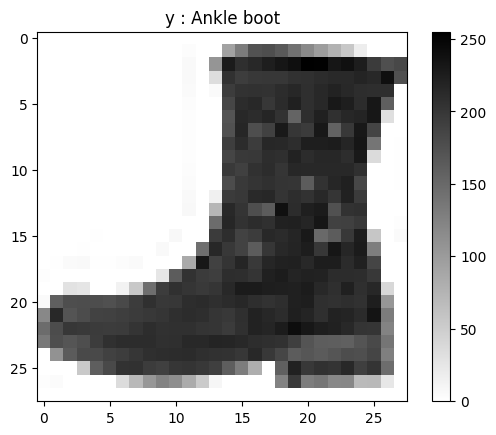

In [5]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 1
i = y_val[n]

plt.imshow(x_val[n], cmap=plt.cm.binary)
plt.title(f'y : {class_names[i]}')
plt.colorbar()
plt.show()

## **(2) 데이터준비**

### 1) 데이터 2차원으로 펼치기

In [6]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((4000, 28, 28), (4000,), (1000, 28, 28), (1000,))

In [7]:
# 펼치기
x_train = x_train.reshape(4000, -1)
x_val = x_val.reshape(1000, -1)

In [8]:
x_train.shape, x_val.shape

((4000, 784), (1000, 784))

### 2) Scaling : Min-Max
* 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
* x_train, x_val를 그냥 255로 나누면 됨

In [9]:
x_train = x_train / 255.
x_val = x_val / 255.

In [10]:
nfeatures = x_train.shape[1]

## (3) 모델링

* 히든레이어의 노드를 다음과 같이 구성합니다.
    * 128, 64, 32, 16, 10
* epoch : 50 ~
* learning_rate : 0.01 ~ 0.0001


### 1) 모델1 : 과적합 모델
* 위에서 제시한 구조대로 모델을 설계하고 학습합니다.

#### ① 모델설계

In [23]:
clear_session()

model = Sequential([Input(shape=(nfeatures,)),
                    Dense(128, activation='relu'),
                    Dense(64, activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(16, activation='relu'),
                    Dense(10, activation='softmax'),
                    ])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

#### ② 학습

In [24]:
result1 = model.fit(x_train, y_train, epochs=50, validation_split=0.2).history

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.6527 - val_loss: 0.7748
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7449 - val_loss: 0.6151
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5760 - val_loss: 0.6137
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5153 - val_loss: 0.5249
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4392 - val_loss: 0.5635
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4486 - val_loss: 0.5221
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4248 - val_loss: 0.4738
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3619 - val_loss: 0.5317
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3548 - val_loss: 0.4700
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3229 - val_loss: 0.5113
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3099 - val_loss: 0.4691
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

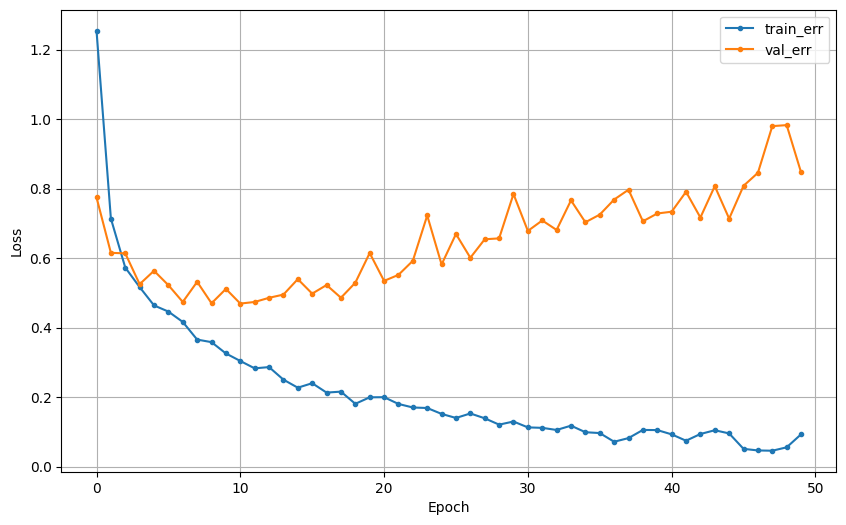

In [25]:
dl_history_plot(result1)

#### ③ 예측 및 검증평가

In [26]:
pred1 = model.predict(x_val)

pred1 = np.argmax(pred1, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [27]:
print(confusion_matrix(y_val, pred1))
print(classification_report(y_val, pred1))

[[ 71   1   3   3   0   0  20   0   1   0]
 [  1 102   1   1   0   0   1   0   0   0]
 [  1   1  71   1   6   0   6   0   1   0]
 [  4   5   2  84   6   0   3   0   0   0]
 [  0   2  15   7  67   0   5   0   3   0]
 [  0   0   0   0   0  82   0   5   0   5]
 [ 10   1  11   6  10   0  54   0   1   0]
 [  0   0   0   0   0   2   0  83   0   8]
 [  0   0   0   1   2   0   5   1  89   0]
 [  0   0   0   0   0   2   0   8   0 119]]
              precision    recall  f1-score   support

           0       0.82      0.72      0.76        99
           1       0.91      0.96      0.94       106
           2       0.69      0.82      0.75        87
           3       0.82      0.81      0.81       104
           4       0.74      0.68      0.71        99
           5       0.95      0.89      0.92        92
           6       0.57      0.58      0.58        93
           7       0.86      0.89      0.87        93
           8       0.94      0.91      0.92        98
           9       0.90     

### 2) early stopping
* 모델1에 대해서, early stopping으로 과적합을 예방해 봅시다.

#### ① 모델설계

In [30]:
clear_session()

model2 = Sequential([Input(shape=(nfeatures,)),
                    Dense(128, activation='relu'),
                    Dense(64, activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(16, activation='relu'),
                    Dense(10, activation='softmax'),
                    ])

model2.summary()

model2.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

#### ② 학습

In [32]:
# EarlyStopping 설정 ------------------
min_de = 0.001
pet = 5

es = EarlyStopping(monitor='val_loss', min_delta=min_de, patience=pet)

result2 = model2.fit(x_train, y_train, epochs=50, validation_split=0.2, callbacks=[es]).history

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.8092 - val_loss: 0.8587
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8115 - val_loss: 0.6050
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5978 - val_loss: 0.5743
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5441 - val_loss: 0.5422
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4469 - val_loss: 0.5257
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4451 - val_loss: 0.4817
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3972 - val_loss: 0.5772
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3928 - val_loss: 0.5657
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3317 - val_loss: 0.5239
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3739 - val_loss: 0.4798
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3138 - val_loss: 0.4592
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5m

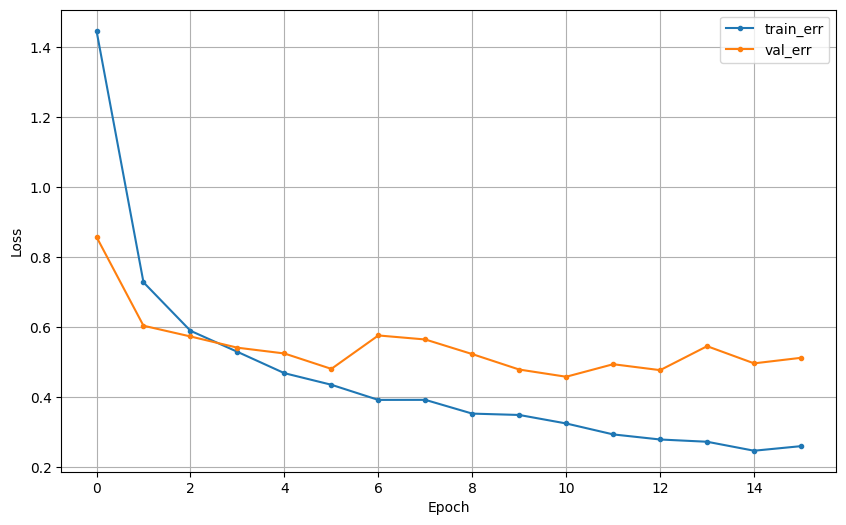

In [33]:
dl_history_plot(result2)

#### ③ 예측 및 검증평가

In [34]:
pred2 = model2.predict(x_val)

pred2 = np.argmax(pred2, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [35]:
print(confusion_matrix(y_val, pred2))
print(classification_report(y_val, pred2))

[[ 79   0   3   5   1   0   7   0   4   0]
 [  0 105   0   1   0   0   0   0   0   0]
 [  2   1  67   1  11   0   4   0   1   0]
 [  2   6   1  88   5   0   2   0   0   0]
 [  0   4  13   7  72   0   2   0   1   0]
 [  0   0   0   0   0  92   0   0   0   0]
 [ 19   0  14   5  19   0  35   0   1   0]
 [  0   0   0   0   0   4   0  83   0   6]
 [  3   0   0   2   1   0   0   1  91   0]
 [  0   0   0   0   0   7   0  11   0 111]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.91      0.99      0.95       106
           2       0.68      0.77      0.72        87
           3       0.81      0.85      0.83       104
           4       0.66      0.73      0.69        99
           5       0.89      1.00      0.94        92
           6       0.70      0.38      0.49        93
           7       0.87      0.89      0.88        93
           8       0.93      0.93      0.93        98
           9       0.95     

### 3) Dropout
* 모델1에 대해서, Dropout으로 과적합을 방지해 봅시다.

#### ① 모델설계

In [36]:
clear_session()

model3 = Sequential([Input(shape=(nfeatures,)),
                    Dense(128, activation='relu'),
                    Dropout(0.4),
                    Dense(64, activation='relu'),
                    Dropout(0.4),
                    Dense(32, activation='relu'),
                    Dropout(0.4),
                    Dense(16, activation='relu'),
                    Dropout(0.4),
                    Dense(10, activation='softmax'),
                    ])

model3.summary()

model3.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

#### ② 학습

In [37]:
result3 = model3.fit(x_train, y_train, epochs=50, validation_split=0.2, verbose=0).history

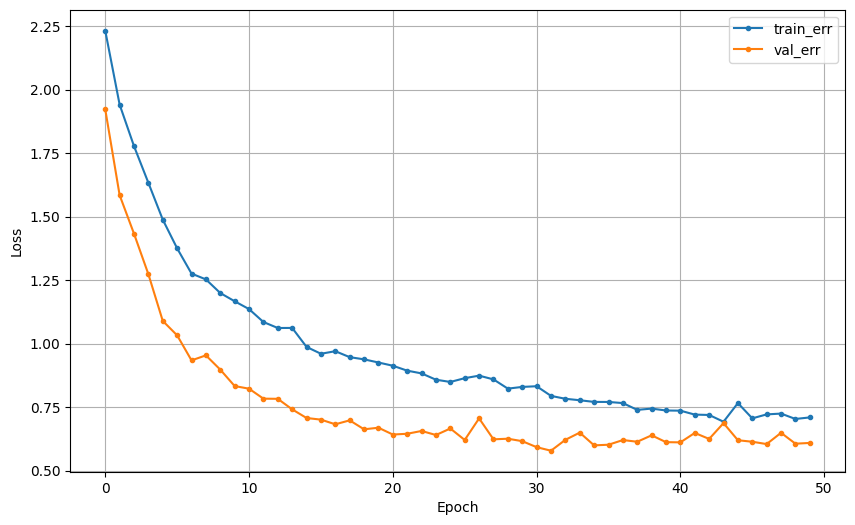

In [38]:
dl_history_plot(result3)

#### ③ 예측 및 검증평가

In [39]:
pred3 = model3.predict(x_val)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [42]:
pred3 = np.argmax(pred3, axis=1)

In [43]:
print(confusion_matrix(y_val, pred3))
print(classification_report(y_val, pred3))

[[ 81   0   7   1   0   0   6   0   4   0]
 [  1 102   1   2   0   0   0   0   0   0]
 [  1   0  37   0  45   0   2   0   2   0]
 [ 11   2   9  72   0   0  10   0   0   0]
 [  0   0  51   0  44   0   3   0   1   0]
 [  0   0   0   0   0  83   0   7   0   2]
 [ 26   0  41   0  20   0   5   0   1   0]
 [  0   0   0   0   0   1   0  89   0   3]
 [  1   0   3   1   0   0   0   1  92   0]
 [  0   0   0   0   0   0   0  18   0 111]]
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        99
           1       0.98      0.96      0.97       106
           2       0.25      0.43      0.31        87
           3       0.95      0.69      0.80       104
           4       0.40      0.44      0.42        99
           5       0.99      0.90      0.94        92
           6       0.19      0.05      0.08        93
           7       0.77      0.96      0.86        93
           8       0.92      0.94      0.93        98
           9       0.96     